> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 5: EDA

## Outline

- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab builds on the cleaned dataset from **Lab 4**. Make sure you've removed outliers and handled missing values before beginning.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

If you have any questions about Colab, you can read more here:  
https://research.google.com/colaboratory/faq.html


## Dataset Overview

**Dataset:** `rent.csv`  
Source: [TidyTuesday – 2022-07-05](https://github.com/rfordatascience/tidytuesday/blob/main/data/2022/2022-07-05/rent.csv)

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## Part 1: Importing the Data

### Instructions:
- Import the `pandas` library for dataframes.  Then `Matplotlib` and `Seaborn` for data visualization.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/rent.csv'
df = pd.read_csv(url)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), object(8)
memory usage: 26.0+ MB


In [48]:
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005,alameda,alameda,alameda,1250,2.0,2.0,NaN,0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005,alameda,alameda,alameda,1295,2.0,NaN,NaN,0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004,alameda,alameda,alameda,1100,2.0,NaN,NaN,0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012,alameda,alameda,alameda,1425,1.0,NaN,735.0,0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004,alameda,alameda,alameda,890,1.0,NaN,NaN,0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


## Part 2: Inspecting, Cleaning & Removing Outliers

### Instructions:
- Identify missing values.
- Check data types are correct(e.g., dates, numeric columns).
- Check for outliers key numeric variables like `price`, `sqft`, `beds`, or `baths`.

### Think about:
- Are there missing values?
- Do the data types look appropriate?
- Do any numeric variables contain extreme or unusual values?


Cleaning Section:

In [49]:
# --- Part 2: Inspecting, Cleaning & Removing Outliers ---

import numpy as np

# 1. Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Example: fill or drop missing values
# beds/baths: fill with median, price/sqft: drop if missing
if 'beds' in df.columns:
    df['beds'] = df['beds'].fillna(df['beds'].median())
if 'baths' in df.columns:
    df['baths'] = df['baths'].fillna(df['baths'].median())
df = df.dropna(subset=['price', 'sqft'])  # critical fields

# 2. Check data types
print("\nData types before conversion:")
print(df.dtypes)

# Convert date to datetime and year to integer
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['year'] = df['date'].dt.year

# Ensure numeric columns are numeric
for col in ['price', 'beds', 'baths', 'sqft']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nData types after conversion:")
print(df.dtypes)

# 3. Summary statistics
print("\nSummary stats:")
print(df[['price', 'beds', 'baths', 'sqft']].describe())

# 4. Remove outliers (1st–99th percentile) for key numeric columns
for col in ['price', 'sqft', 'beds', 'baths']:
    if col in df.columns:
        q_low = df[col].quantile(0.01)
        q_high = df[col].quantile(0.99)
        df = df[(df[col] >= q_low) & (df[col] <= q_high)]

print("\nRows after cleaning:", len(df))

# 5. Quick preview
df.head()

Missing values per column:
post_id             0
date                0
year                0
nhood               0
city                0
county           1394
price               0
beds             6608
baths          158121
sqft           136117
room_in_apt         0
address        196888
lat            193145
lon            196484
title            2517
descr          197542
details        192780
dtype: int64

Data types before conversion:
post_id         object
date             int64
year             int64
nhood           object
city            object
county          object
price            int64
beds           float64
baths          float64
sqft           float64
room_in_apt      int64
address         object
lat            float64
lon            float64
title           object
descr           object
details         object
dtype: object

Data types after conversion:
post_id                object
date           datetime64[ns]
year                    int32
nhood                  object


,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
3,pre2013_68671,1970-01-01 00:00:00.020120601,1970,alameda,alameda,alameda,1425,1.0,2.0,735.0,0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
11,pre2013_57782,1970-01-01 00:00:00.020120311,1970,alameda,alameda,alameda,3900,5.0,2.0,2581.0,0,NaN,NaN,NaN,$3900 / 5br - 2581ft² - Gorgeous Restored Vict...,NaN,NaN
12,4168358289,1970-01-01 00:00:00.020131103,1970,alameda,alameda,alameda,2595,4.0,3.0,1756.0,0,NaN,37.534936,NaN,Nov 2 Newly remodeled 4br/3ba (2 mastersuites...,NaN,"<p class=""row"" data-latitude=""37.534936"" data-..."
14,5536682206,1970-01-01 00:00:00.020160413,1970,alameda,alameda,alameda,4895,4.0,2.0,2499.0,0,NaN,NaN,NaN,"Nis 12 4Br/3Ba, Alameda Executive home by Mari...",NaN,NaN
15,5536747083,1970-01-01 00:00:00.020160413,1970,alameda,alameda,alameda,1800,1.0,2.0,650.0,0,NaN,NaN,NaN,Nis 12 All New 1 Bedroom in Alameda $1800 / ...,NaN,NaN


In [50]:
# Check for missing values
df.isnull().sum()

,0
post_id,0
date,0
year,0
nhood,0
city,0
county,473
price,0
beds,0
baths,0
sqft,0


In [51]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,61866.000000,61866.000000,61866.000000,61866.000000
mean,2529.915236,2.002667,1.931691,1121.116672
std,1160.716940,1.002047,0.322950,518.298866
min,800.000000,0.000000,1.000000,335.000000
25%,1725.000000,1.000000,2.000000,750.000000
50%,2299.000000,2.000000,2.000000,1000.000000
75%,3000.000000,3.000000,2.000000,1325.000000
max,8500.000000,5.000000,3.000000,3400.000000


In [52]:
# Check data types
df.dtypes

,0
post_id,object
date,datetime64[ns]
year,int32
nhood,object
city,object
county,object
price,int64
beds,float64
baths,float64
sqft,float64


In [53]:
# Remove price outliers (1st–99th percentile)
q_low = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
df = df[(df['price'] >= q_low) & (df['price'] <= q_high)]

## Part 3: Basic Exploration

Use `groupby` and `value_counts` to summarize trends across neighborhoods and cities.


In [54]:
# Average price by neighborhood
df.groupby('nhood')['price'].mean().sort_values(ascending=False).head(10)

,price
nhood,
inverness,4950.000000
montara,4300.000000
haight ashbury,4125.580247
pacific heights,4085.341902
NOPA,4061.891089
saratoga,4019.162791
west portal / forest hills,3939.742857
treasure island,3893.666667
SOMA / south beach,3872.007614


In [55]:
# Top cities by count
df['city'].value_counts().head(10)

,count
city,
san francisco,9427
san jose,6597
santa rosa,2437
santa cruz,2346
sunnyvale,2195
santa clara,2072
oakland,1627
union city,1620
mountain view,1607


## Part 4: Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


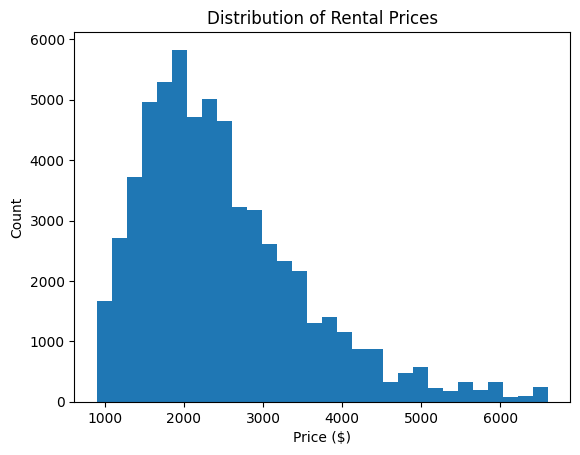

In [56]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

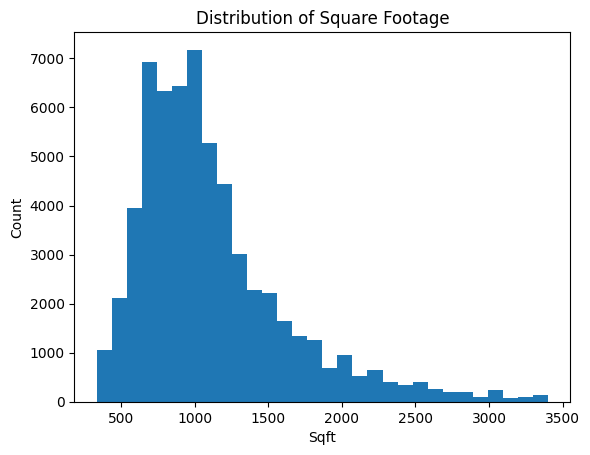

In [57]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


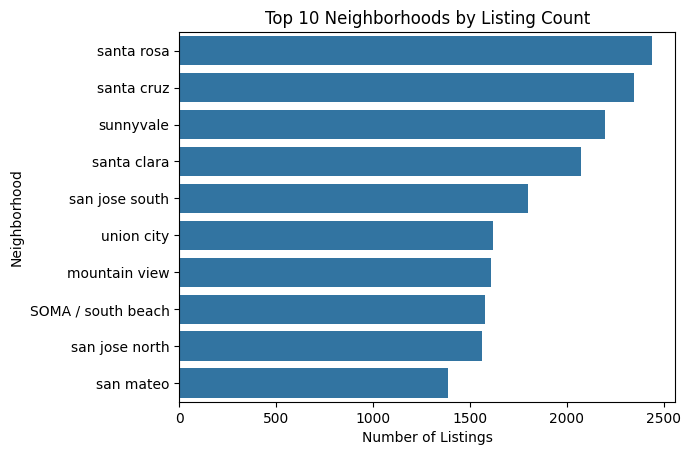

In [58]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

sns.barplot(x=top_nhoods.values, y=top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.show()

### 🔧 Try It Yourself – Part 4

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

2. After creating the visuals, write 1–2 sentences explaining what you notice in each.


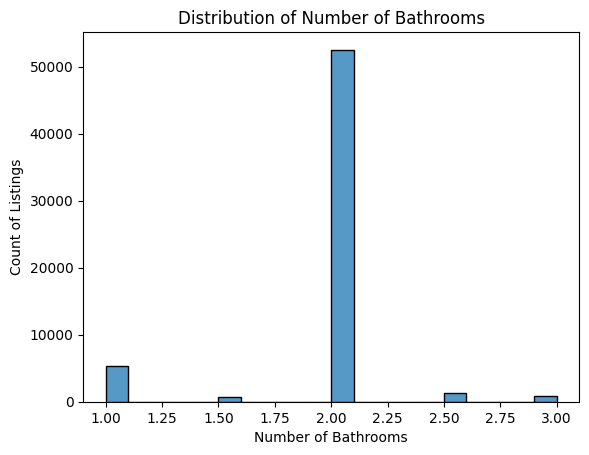

In [59]:
# Visual 1: Histogram of number of bathrooms
sns.histplot(df['baths'], bins=20, kde=False)
plt.title("Distribution of Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count of Listings")
plt.show()

🔧 Visual 1 comment: Most listings have 1–2 bathrooms, with very few listings offering more than 4

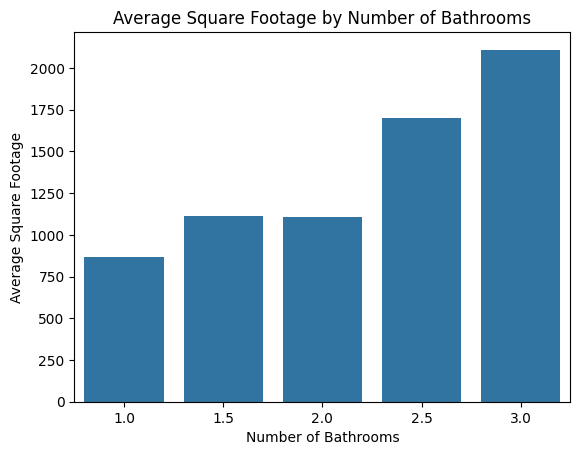

In [60]:
# Visual 2: Bar chart of average square footage by number of bathrooms
avg_sqft_by_baths = df.groupby('baths')['sqft'].mean().reset_index()

sns.barplot(data=avg_sqft_by_baths, x='baths', y='sqft')
plt.title("Average Square Footage by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Square Footage")
plt.show()

🔧 Visual 2 comment: Average square footage increases as the number of bathrooms increases, which makes sense since larger homes usually have more bathrooms.

## Part 5: Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [61]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.363399,0.115054,0.482119
beds,0.363399,1.000000,0.213027,0.797547
baths,0.115054,0.213027,1.000000,0.251302
sqft,0.482119,0.797547,0.251302,1.000000


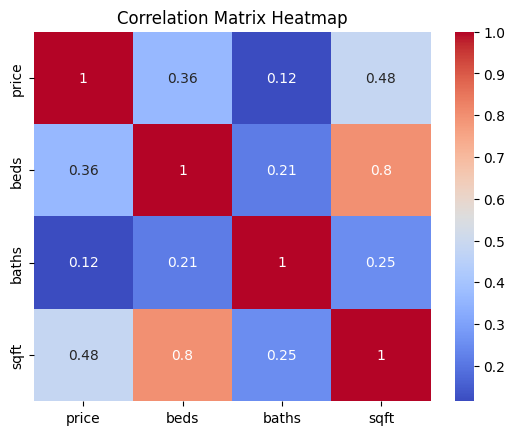

In [62]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

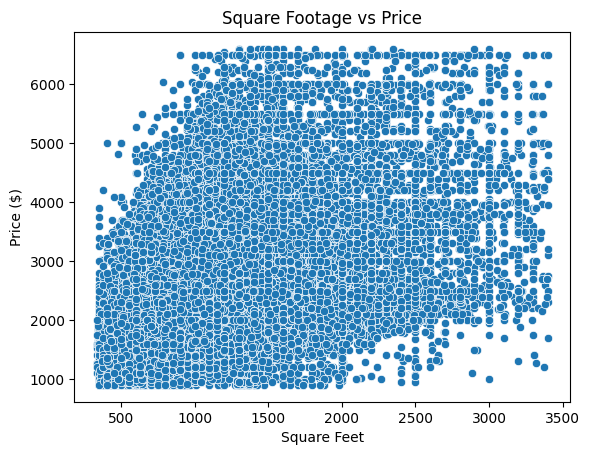

In [63]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

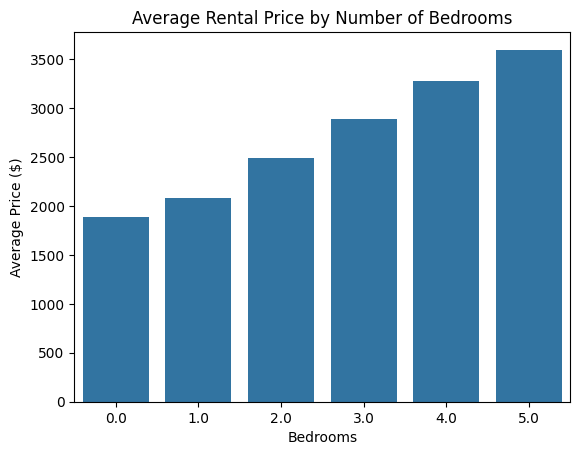

In [64]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### 🔧 Try It Yourself – Part 5

1. Create a scatterplot of `baths` vs `price`.  
2. Group by `year` and plot the average price over time.
3. What trends or outliers do you see?

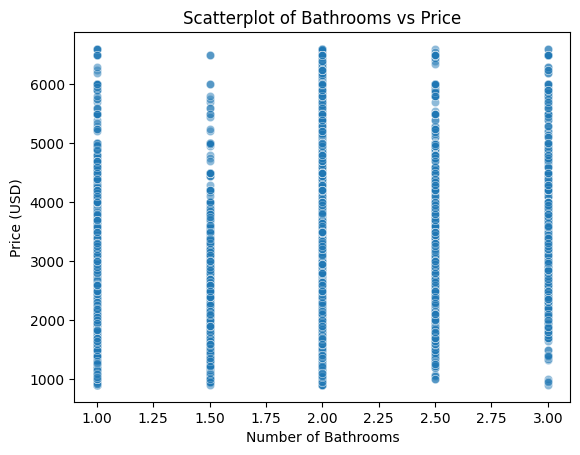

In [65]:
# Scatterplot of baths vs price
sns.scatterplot(data=df, x='baths', y='price', alpha=0.5)
plt.title("Scatterplot of Bathrooms vs Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (USD)")
plt.show()

In [66]:
# --- Fix the year column ---

# Make sure 'date' is a datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract year from the date
df['year'] = df['date'].dt.year

# Quick check: how many years are in the data
print(df['year'].value_counts().sort_index())

year
1970    60745
Name: count, dtype: int64


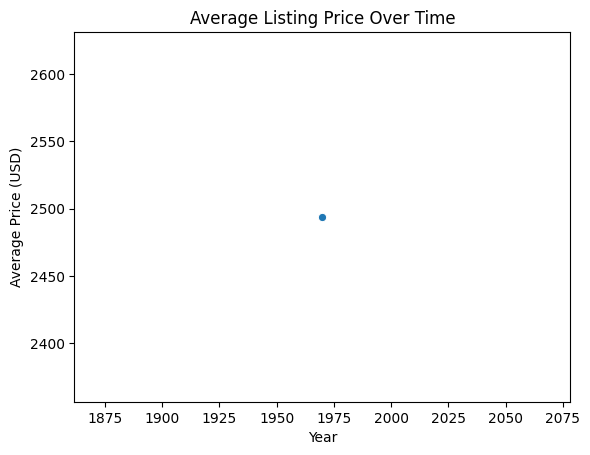

In [67]:
# Average price by year
avg_price_by_year = df.groupby('year')['price'].mean().reset_index()

sns.lineplot(data=avg_price_by_year, x='year', y='price', marker='o')
plt.title("Average Listing Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.show()

🔧 Add comment here: For the scatter plot of baths vs price, it looks like listings with more bathrooms generally have higher prices, though there are some extreme outliers with unusually high prices. For the average price per year chart, average rent prices show an upward trend over time, but some years appear to spike more sharply than others, maybe due to outliers or market shifts.

## 🔧  Part 6: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

1. Which variables are most strongly correlated with rental price?
2. Are there patterns in how size (sqft) or number of bedrooms affects price?
3. Which neighborhoods or years show the highest prices?
4. What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

🔧 Add refections here:

Which variables are most strongly correlated with rental price?
Rental price is most strongly correlated with square footage (sqft) and number of bathrooms. Larger properties with more bathrooms typically have higher prices.

Are there patterns in how size (sqft) or number of bedrooms affects price?
Yes, average prices increase as square footage and bedrooms increase. However, there are diminishing returns at higher bedroom counts, suggesting other factors also influence price.

Which neighborhoods or years show the highest prices?
Neighborhood-level variation is clear, with some areas consistently having higher average prices. The dataset only covers one year, so no multi-year trends are visible.

What other visualizations or groupings might improve this analysis?
Additional visualizations such as boxplots of price by city/neighborhood or scatterplots of price per square foot vs. latitude/longitude would help highlight location effects. Grouping by property type (room vs. apartment) could also add insight.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [ ]:
!jupyter nbconvert --to html "lab_05_LastnameFirstname.ipynb"